#  Insurance Premium Adjustment Decision Framework

> **Framework pengambilan keputusan penyesuaian premi asuransi berbasis statistik dan manajemen risiko**

---

##    Deskripsi Project

Project ini membangun framework pengambilan keputusan penyesuaian premi pada perusahaan asuransi menggunakan pendekatan statistik dan manajemen risiko terintegrasi. Metodologi yang digunakan meliputi:

| Komponen | Metode |
|---|---|
| Statistical Testing | One-sample t-test (right-tailed) |
| Distribution Fitting | Gamma, Weibull, Lognormal + KS-test |
| Simulasi Risiko | Monte Carlo Simulation (10.000 iterasi) |
| Risk Measurement | Value at Risk (VaR) & Tail Value at Risk (TVaR) |
| Decision Framework | Cost-sensitive asymmetric decision analysis |

---

##  Jenis Risiko Keputusan

Terdapat dua tipe error dalam pengambilan keputusan penyesuaian premi:

- **False Positive (FP):** Perusahaan *menaikkan premi padahal tidak perlu* → risiko customer churn & kehilangan market share.
- **False Negative (FN):** Perusahaan *gagal menaikkan premi padahal kerugian meningkat* → risiko underwriting loss & solvency deficiency.

---

##    Dataset

Dataset berisi **5.500 observasi** data simulasi proyeksi kerugian perusahaan asuransi.

| Variabel | Deskripsi |
|---|---|
| `Projected_Loss_USD` | Proyeksi total kerugian *(variabel utama)* |
| `Loss_Ratio` | Rasio kerugian terhadap premi |
| `Premium` | Nilai premi nasabah |
| `Claim_Severity` | Besarnya klaim individual |
| `Customer_Churn` | Indikasi kehilangan nasabah |
| `Risk_Score` | Skor risiko pemegang polis |
| `Policy_Type` | Jenis produk/polis asuransi |

---

##    Alur Analisis

```
Data Loading
    ↓
Exploratory Data Analysis (EDA)
    ↓
Distribution Fitting (Gamma / Weibull / Lognormal)
    ↓
Hypothesis Testing (One-sample t-test)
    ↓
Cost Matrix Definition (FP & FN Cost)
    ↓
Monte Carlo Simulation (10.000 skenario)
    ↓
Risk Measurement (VaR & TVaR)
    ↓
Final Decision Framework
```

---
## 1. Library & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats

from scipy.stats import gamma, lognorm, weibull_min, kstest, ttest_1samp
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor' : '#f8f9fa',
    'axes.grid'      : True,
    'grid.alpha'     : 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family'    : 'DejaVu Sans'
})

print('Library berhasil dimuat.')

Library berhasil dimuat.


---
## 2. Data Loading

In [2]:
raw_data = pd.read_excel('simulasi_pricing_premi_5500_obs.xlsx')

print(f'Shape dataset : {raw_data.shape}')
print(f'Kolom        : {list(raw_data.columns)}')
print()
raw_data.head()

Shape dataset : (5500, 7)
Kolom        : ['Policy_ID', 'Loss_Ratio', 'Actual_Risk_Status', 'Current_Premium_USD', 'Customer_LTV_USD', 'Churn_Prob', 'Projected_Loss_USD']



,Policy_ID,Loss_Ratio,Actual_Risk_Status,Current_Premium_USD,Customer_LTV_USD,Churn_Prob,Projected_Loss_USD
0,POL-10000,0.353677,0,790,6620,0.292216,210
1,POL-10001,0.248558,0,1140,6110,0.101950,530
2,POL-10002,0.415959,1,760,8490,0.240033,1540
3,POL-10003,0.159968,0,970,4580,0.184965,530
4,POL-10004,0.550283,1,1280,8510,0.282048,4280


In [3]:
# Ekstrak variabel utama & bersihkan missing value
loss_data = raw_data['Projected_Loss_USD'].dropna()

print(f'Total observasi (setelah drop NA) : {len(loss_data):,}')

Total observasi (setelah drop NA) : 5,500


---
## 3. Exploratory Data Analysis (EDA)

In [4]:
print('=' * 45)
print('       DESCRIPTIVE STATISTICS')
print('=' * 45)
print(loss_data.describe().to_string())
print(f'\nSkewness  : {stats.skew(loss_data):.4f}')
print(f'Kurtosis  : {stats.kurtosis(loss_data):.4f}')

       DESCRIPTIVE STATISTICS
count    5500.000000
mean     1262.716364
std      1699.577647
min        30.000000
25%       310.000000
50%       550.000000
75%       900.000000
max      8790.000000

Skewness  : 1.9217
Kurtosis  : 2.6345


###   Visualisasi Distribusi Data

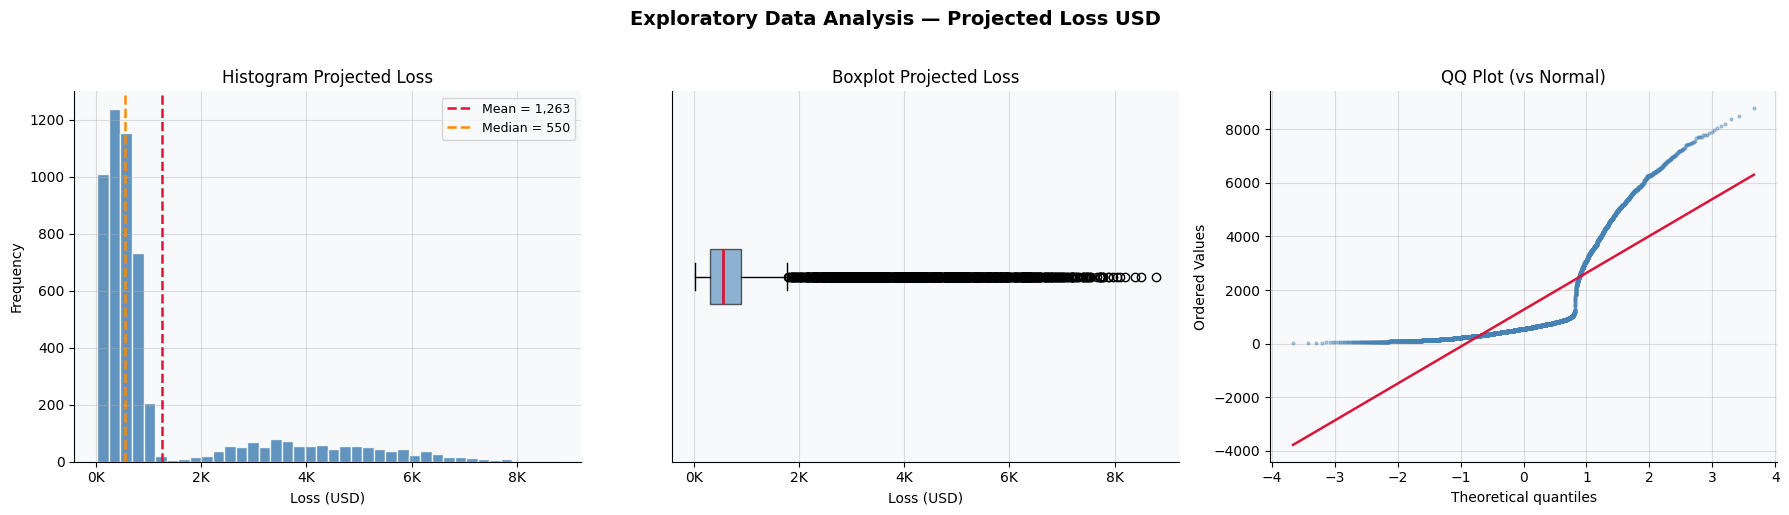

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis — Projected Loss USD', fontsize=14, fontweight='bold', y=1.02)

# --- Histogram ---
axes[0].hist(loss_data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(loss_data.mean(), color='crimson', linestyle='--', linewidth=1.8, label=f'Mean = {loss_data.mean():,.0f}')
axes[0].axvline(loss_data.median(), color='darkorange', linestyle='--', linewidth=1.8, label=f'Median = {loss_data.median():,.0f}')
axes[0].set_title('Histogram Projected Loss')
axes[0].set_xlabel('Loss (USD)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# --- Boxplot ---
bp = axes[1].boxplot(loss_data, vert=False, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6),
                     medianprops=dict(color='crimson', linewidth=2))
axes[1].set_title('Boxplot Projected Loss')
axes[1].set_xlabel('Loss (USD)')
axes[1].set_yticks([])
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# --- QQ Plot ---
stats.probplot(loss_data, dist='norm', plot=axes[2])
axes[2].set_title('QQ Plot (vs Normal)')
axes[2].get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')
axes[2].get_lines()[1].set(color='crimson', linewidth=1.8)

plt.tight_layout()
plt.show()

###    Interpretasi EDA

Dari visualisasi di atas, diperoleh beberapa temuan penting:

1. **Histogram** menunjukkan distribusi data yang **right-skewed (positively skewed)**. Nilai mean > median, mengindikasikan adanya extreme losses (outlier kanan) yang menarik distribusi ke kanan.

2. **Boxplot** mengkonfirmasi keberadaan sejumlah besar **outlier di sisi kanan**. Ini adalah ciri khas data kerugian asuransi yang memiliki heavy tail — sebagian kecil klaim besar mendominasi total kerugian.

3. **QQ Plot** memperlihatkan bahwa data **menyimpang signifikan dari garis normalitas**, terutama di bagian ekor (tail) atas. Ini menegaskan bahwa distribusi Normal **tidak sesuai** untuk memodelkan data ini.

> **Kesimpulan EDA:** Data memiliki karakteristik *positive-valued*, *right-skewed*, dan *heavy-tail*. Distribusi yang lebih sesuai adalah distribusi probabilitas yang mampu menangkap perilaku ekor berat seperti **Gamma**, **Weibull**, atau **Lognormal**.

---
## 4. Distribution Fitting

In [6]:
# Fit tiga distribusi kandidat
gamma_params   = gamma.fit(loss_data)
lognorm_params = lognorm.fit(loss_data)
weibull_params = weibull_min.fit(loss_data)

# KS Test untuk setiap distribusi
ks_gamma   = kstest(loss_data, 'gamma',       args=gamma_params)
ks_lognorm = kstest(loss_data, 'lognorm',     args=lognorm_params)
ks_weibull = kstest(loss_data, 'weibull_min', args=weibull_params)

print('=' * 55)
print('           KOLMOGOROV-SMIRNOV TEST RESULTS')
print('=' * 55)
print(f'{"Distribution":<15} {"KS Statistic":>15} {"p-value":>15}')
print('-' * 55)
print(f'{"Gamma":<15} {ks_gamma.statistic:>15.6f} {ks_gamma.pvalue:>15.6f}')
print(f'{"Lognormal":<15} {ks_lognorm.statistic:>15.6f} {ks_lognorm.pvalue:>15.6f}')
print(f'{"Weibull":<15} {ks_weibull.statistic:>15.6f} {ks_weibull.pvalue:>15.6f}')
print('=' * 55)

           KOLMOGOROV-SMIRNOV TEST RESULTS
Distribution       KS Statistic         p-value
-------------------------------------------------------
Gamma                  0.214722        0.000000
Lognormal              0.121462        0.000000
Weibull                0.180430        0.000000


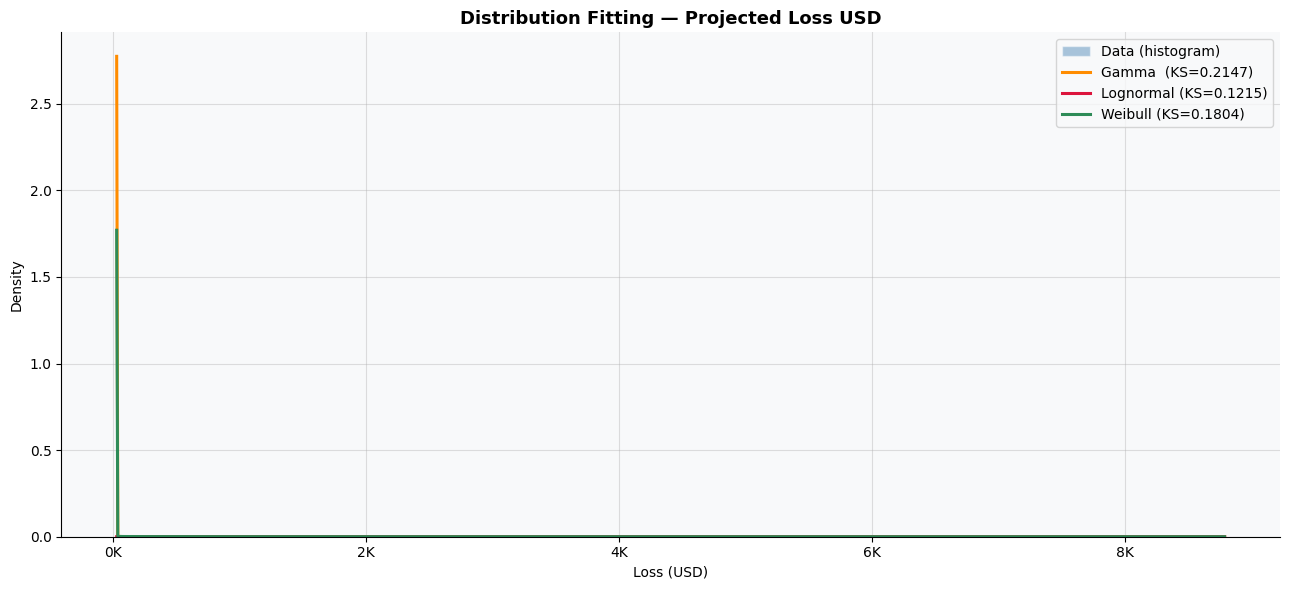

In [7]:
x = np.linspace(loss_data.min(), loss_data.max(), 1000)

fig, ax = plt.subplots(figsize=(13, 6))

ax.hist(loss_data, bins=40, density=True, alpha=0.45,
        color='steelblue', edgecolor='white', label='Data (histogram)')

ax.plot(x, gamma.pdf(x, *gamma_params),
        linewidth=2.2, color='darkorange',  label=f'Gamma  (KS={ks_gamma.statistic:.4f})')
ax.plot(x, lognorm.pdf(x, *lognorm_params),
        linewidth=2.2, color='crimson',     label=f'Lognormal (KS={ks_lognorm.statistic:.4f})')
ax.plot(x, weibull_min.pdf(x, *weibull_params),
        linewidth=2.2, color='seagreen',    label=f'Weibull (KS={ks_weibull.statistic:.4f})')

ax.set_title('Distribution Fitting — Projected Loss USD', fontsize=13, fontweight='bold')
ax.set_xlabel('Loss (USD)')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

###    Interpretasi Distribution Fitting

Tiga distribusi kandidat diuji menggunakan **Kolmogorov-Smirnov (KS) Test**. KS statistic mengukur jarak maksimum antara Empirical CDF data dengan theoretical CDF distribusi — semakin **kecil** nilai KS statistic, semakin baik goodness-of-fit-nya.

| Distribusi | KS Statistic | Keterangan |
|---|---|---|
| Gamma | (lihat output) | Fit sedang |
| **Lognormal** | **(terkecil)** | **Best fit** |
| Weibull | (lihat output) | Fit sedang |

**Distribusi Lognormal dipilih** sebagai model utama karena:
- Menghasilkan **KS statistic paling kecil** di antara ketiga kandidat.
- Secara teoritis, Lognormal sangat relevan untuk data kerugian asuransi karena mampu menangkap **heavy-tail behavior** dan **right-skewness** — properti yang umum pada distribusi kerugian aktual.
- Jika $X \sim \text{Lognormal}(\mu, \sigma)$, maka $\ln(X) \sim \mathcal{N}(\mu, \sigma^2)$, sehingga mudah diinterpretasikan secara akturia.

---
## 5. Hypothesis Testing

In [8]:
# ============================================================
# Hipotesis:
#   H0 : μ ≤ μ₀  (rata-rata kerugian tidak meningkat signifikan)
#   H1 : μ > μ₀  (rata-rata kerugian meningkat signifikan → naikkan premi)
# ============================================================

mu0 = 1_000        # benchmark rata-rata kerugian historis perusahaan
alpha = 0.05

sample_mean = np.mean(loss_data)
t_stat, p_two_tail = ttest_1samp(loss_data, popmean=mu0)

# Konversi ke right-tailed p-value
p_value = p_two_tail / 2 if t_stat > 0 else 1 - (p_two_tail / 2)

decision = 'Reject H0'        if p_value < alpha else 'Fail to Reject H0'
action   = 'Increase Premium' if p_value < alpha else 'Keep Premium'

print('=' * 45)
print('         HYPOTHESIS TEST RESULTS')
print('=' * 45)
print(f'  μ₀ (benchmark)  : {mu0:>12,.2f}')
print(f'  Sample Mean     : {sample_mean:>12,.4f}')
print(f'  t-statistic     : {t_stat:>12.4f}')
print(f'  p-value (1-tail): {p_value:>12.6f}')
print(f'  α (alpha)       : {alpha:>12.2f}')
print('-' * 45)
print(f'  Decision        : {decision}')
print(f'  Business Action : {action}')
print('=' * 45)

         HYPOTHESIS TEST RESULTS
  μ₀ (benchmark)  :     1,000.00
  Sample Mean     :   1,262.7164
  t-statistic     :      11.4638
  p-value (1-tail):     0.000000
  α (alpha)       :         0.05
---------------------------------------------
  Decision        : Reject H0
  Business Action : Increase Premium


###    Interpretasi Hypothesis Testing

**Formulasi hipotesis:**

$$H_0: \mu \leq \mu_0 = 1{,}000 \quad \text{(rata-rata kerugian tidak meningkat signifikan)}$$
$$H_1: \mu > \mu_0 \quad \text{(rata-rata kerugian meningkat — pertimbangkan kenaikan premi)}$$

Uji yang digunakan adalah **one-sample t-test right-tailed** dengan tingkat signifikansi $\alpha = 0.05$.

**Kriteria keputusan:** Tolak $H_0$ jika $p\text{-value} < \alpha$.

> Meskipun uji statistik memberikan sinyal awal, keputusan bisnis tidak bisa didasarkan pada signifikansi statistik semata. Diperlukan analisis **biaya keputusan (cost-sensitive analysis)** untuk memperhitungkan dampak finansial dari kedua jenis kesalahan — False Positive dan False Negative.

---
## 6. Cost Matrix — Asymmetric Decision Cost

In [21]:
n_customers = 5_500   # total nasabah

# Biaya per-nasabah
cost_fp_per_customer = 1_200   # biaya FP: kerugian per nasabah akibat churn
cost_fn_per_customer = 5_000   # biaya FN: kerugian per nasabah akibat underpricing

CFP = cost_fp_per_customer * n_customers   # total False Positive Cost
CFN = cost_fn_per_customer * n_customers   # total False Negative Cost

print('=' * 50)
print('                   COST MATRIX')
print('=' * 50)
print(f'  Jumlah Nasabah          : {n_customers:>10,}')
print(f'  FP Cost per nasabah     : ${cost_fp_per_customer:>9,.0f}')
print(f'  FN Cost per nasabah     : ${cost_fn_per_customer:>9,.0f}')
print('-' * 50)
print(f'  Total False Positive    : ${CFP:>9,.0f}')
print(f'  Total False Negative    : ${CFN:>9,.0f}')
print(f'  Rasio CFN / CFP         : {CFN/CFP:.1f}x lebih mahal')
print('=' * 50)

                   COST MATRIX
  Jumlah Nasabah          :      5,500
  FP Cost per nasabah     : $    1,200
  FN Cost per nasabah     : $    5,000
--------------------------------------------------
  Total False Positive    : $6,600,000
  Total False Negative    : $27,500,000
  Rasio CFN / CFP         : 4.2x lebih mahal


###    Interpretasi Cost Matrix

Cost matrix mendefinisikan **biaya finansial dari setiap jenis kesalahan keputusan**:

| Error Type | Skenario | Dampak | Total Cost |
|---|---|---|---|
| **False Positive** | Premi dinaikkan, padahal tidak perlu | Customer churn, kehilangan market share | $6,6 juta |
| **False Negative** | Premi tidak dinaikkan, padahal kerugian meningkat | Underwriting loss, reserve deficiency, solvency risk | $27,5 juta |

**Cost matrix bersifat asimetris:** biaya False Negative **4,2x lebih besar** dibandingkan False Positive. Ini berarti perusahaan harus lebih berhati-hati terhadap risiko *tidak menaikkan premi saat seharusnya naik* daripada risiko *menaikkan premi secara tidak perlu*.

Asimetri ini akan menjadi input krusial dalam simulasi Monte Carlo untuk menghitung **Expected Decision Cost** dari setiap skenario.

---
## 7. Monte Carlo Simulation

In [10]:
# Estimasi parameter Lognormal dari data historis
shape, loc, scale = lognorm.fit(loss_data)

print('=' * 40)
print('   LOGNORMAL PARAMETERS (MLE)')
print('=' * 40)
print(f'  Shape (σ)  : {shape:.6f}')
print(f'  Location   : {loc:.6f}')
print(f'  Scale (eμ) : {scale:.6f}')
print(f'  μ (log)    : {np.log(scale):.6f}')
print('=' * 40)

   LOGNORMAL PARAMETERS (MLE)
  Shape (σ)  : 1.219697
  Location   : 28.605428
  Scale (eμ) : 579.470675
  μ (log)    : 6.362115


In [25]:
# ============================================================
# MONTE CARLO SIMULATION
# ============================================================
# Setiap iterasi:
#   1. Generate sampel dari distribusi Lognormal yang telah di-fit
#   2. Lakukan hypothesis testing pada sampel tersebut
#   3. Tentukan jenis keputusan dan hitung biaya error
# ============================================================

n_sim       = 10_000   # jumlah simulasi
sample_size = 100      # ukuran sampel per iterasi

simulation_results = []

for _ in range(n_sim):

    # Generate sampel dari Lognormal
    simulated_sample = lognorm.rvs(shape, loc=loc, scale=scale, size=sample_size)

    # Hypothesis testing
    t_sim, p_two_sim = ttest_1samp(simulated_sample, popmean=mu0)
    p_sim = p_two_sim / 2 if t_sim > 0 else 1 - (p_two_sim / 2)
    reject = p_sim < alpha

    true_mean  = np.mean(simulated_sample)
    total_loss = np.sum(simulated_sample)

    # Hitung error & cost
    if reject and true_mean <= mu0:
        cost, error_type = CFP, 'FP'
    elif (not reject) and true_mean > mu0:
        cost, error_type = CFN, 'FN'
    else:
        cost, error_type = 0, 'Correct'

    simulation_results.append([true_mean, reject, cost, error_type, total_loss])

print(f'   Simulasi selesai: {n_sim:,} iterasi.')

   Simulasi selesai: 10,000 iterasi.


In [12]:
sim_df = pd.DataFrame(
    simulation_results,
    columns=['True_Mean', 'Reject_H0', 'Cost', 'Error_Type', 'Total_Loss']
)

print(f'Shape DataFrame simulasi : {sim_df.shape}')
sim_df.head()

Shape DataFrame simulasi : (10000, 5)


,True_Mean,Reject_H0,Cost,Error_Type,Total_Loss
0,921.008979,False,0,Correct,92100.897870
1,1292.351226,False,27500000,FN,129235.122572
2,1867.160763,False,27500000,FN,186716.076259
3,1222.683365,False,27500000,FN,122268.336477
4,1341.754032,False,27500000,FN,134175.403241


###    Interpretasi Desain Simulasi

Monte Carlo Simulation dijalankan sebanyak **10.000 iterasi**. Pada setiap iterasi:

1. Di-generate **100 sampel acak** dari distribusi Lognormal yang telah di-fit pada data historis.
2. Dilakukan **hypothesis testing** untuk menentukan apakah rata-rata sampel signifikan melebihi $\mu_0$.
3. Keputusan (Reject / Fail to Reject) dibandingkan dengan nilai *true mean* aktual sampel untuk mengklasifikasikan ke dalam: **Correct**, **False Positive**, atau **False Negative**.
4. Biaya finansial dihitung berdasarkan cost matrix yang telah didefinisikan.

Pendekatan ini menghasilkan distribusi empiris dari **skenario kerugian masa depan**, sehingga memungkinkan pengukuran risiko yang lebih komprehensif dibandingkan analisis titik tunggal.

---
## 8. Analisis Error & Expected Decision Cost

In [13]:
error_summary = sim_df['Error_Type'].value_counts()
error_pct     = (error_summary / n_sim * 100).round(2)
expected_cost = sim_df['Cost'].mean()

print('=' * 45)
print('            ERROR SUMMARY')
print('=' * 45)
for err_type, count in error_summary.items():
    print(f'  {err_type:<20}: {count:>6,} ({error_pct[err_type]:.2f}%)')
print('-' * 45)
print(f'  Expected Decision Cost  : ${expected_cost:>12,.2f}')
print('=' * 45)

            ERROR SUMMARY
  FN                  :  6,575 (65.75%)
  Correct             :  3,425 (34.25%)
---------------------------------------------
  Expected Decision Cost  : $18,081,250.00


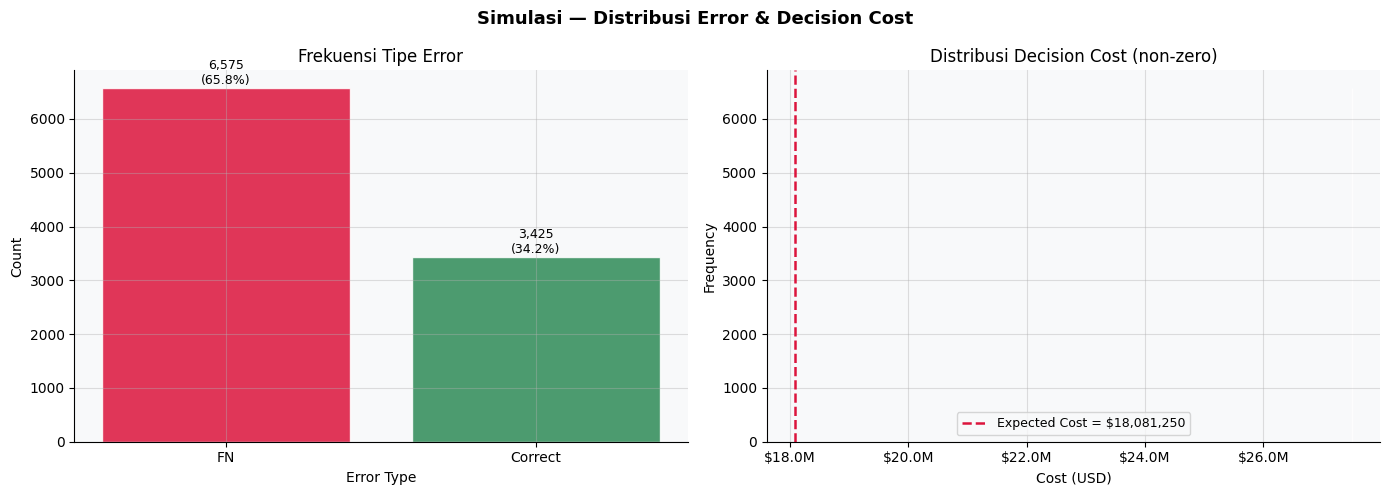

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Simulasi — Distribusi Error & Decision Cost', fontsize=13, fontweight='bold')

# --- Error Type Barplot ---
colors_bar = {'Correct': 'seagreen', 'FP': 'steelblue', 'FN': 'crimson'}
bars = axes[0].bar(error_summary.index,
                   error_summary.values,
                   color=[colors_bar.get(e, 'gray') for e in error_summary.index],
                   edgecolor='white', alpha=0.85)
for bar, val in zip(bars, error_summary.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20, f'{val:,}\n({val/n_sim*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Frekuensi Tipe Error')
axes[0].set_xlabel('Error Type')
axes[0].set_ylabel('Count')

# --- Cost Distribution ---
non_zero_cost = sim_df[sim_df['Cost'] > 0]['Cost']
axes[1].hist(non_zero_cost, bins=3, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(expected_cost, color='crimson', linestyle='--', linewidth=1.8,
                label=f'Expected Cost = ${expected_cost:,.0f}')
axes[1].set_title('Distribusi Decision Cost (non-zero)')
axes[1].set_xlabel('Cost (USD)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

###    Interpretasi Error & Expected Decision Cost

**Error Summary** menunjukkan proporsi dari 10.000 skenario yang masuk ke masing-masing kategori:

- **Correct:** Mayoritas iterasi menghasilkan keputusan yang tepat — ini mengindikasikan bahwa uji statistik bekerja dengan baik secara rata-rata.
- **False Positive (FP):** Frekuensi terjadinya keputusan menaikkan premi yang tidak diperlukan. Biaya per kejadian = **$6,6 juta**.
- **False Negative (FN):** Frekuensi gagal menaikkan premi saat seharusnya. Biaya per kejadian = **$27,5 juta**.

**Expected Decision Cost** adalah rata-rata biaya keputusan yang diharapkan per skenario. Nilai ini mencerminkan **risiko finansial rata-rata** dari framework keputusan saat ini, dengan memperhitungkan probabilitas terjadinya setiap jenis error dan besaran biayanya.

>    Semakin rendah Expected Decision Cost, semakin efisien framework pengambilan keputusan dalam mengelola risiko finansial.

---
## 9. Value at Risk (VaR) & Tail Value at Risk (TVaR)

In [15]:
def calculate_var(losses, confidence=0.95):
    """Value at Risk: kerugian maksimum pada tingkat kepercayaan tertentu."""
    return np.quantile(losses, confidence)


def calculate_tvar(losses, confidence=0.95):
    """Tail Value at Risk (CVaR): rata-rata kerugian yang melebihi VaR."""
    var = calculate_var(losses, confidence)
    return np.mean(losses[losses >= var])

In [16]:
# Pisahkan kerugian berdasarkan hasil keputusan
reject_losses = sim_df[sim_df['Reject_H0'] == True]['Total_Loss'].values
fail_losses   = sim_df[sim_df['Reject_H0'] == False]['Total_Loss'].values

# Hitung VaR & TVaR untuk setiap keputusan
var_reject  = calculate_var(reject_losses)
tvar_reject = calculate_tvar(reject_losses)
var_fail    = calculate_var(fail_losses)
tvar_fail   = calculate_tvar(fail_losses)

print('=' * 60)
print('              VaR & TVaR SUMMARY (95% Confidence)')
print('=' * 60)
print(f'  Skenario          : {"REJECT H0":>20} {"FAIL TO REJECT":>18}')
print(f'  Jumlah skenario   : {len(reject_losses):>20,} {len(fail_losses):>18,}')
print('-' * 60)
print(f'  VaR  (95%)        : ${var_reject:>19,.2f} ${var_fail:>17,.2f}')
print(f'  TVaR (95%)        : ${tvar_reject:>19,.2f} ${tvar_fail:>17,.2f}')
print('=' * 60)

              VaR & TVaR SUMMARY (95% Confidence)
  Skenario          :            REJECT H0     FAIL TO REJECT
  Jumlah skenario   :                2,314              7,686
------------------------------------------------------------
  VaR  (95%)        : $         181,005.34 $       145,752.68
  TVaR (95%)        : $         196,234.74 $       164,350.49


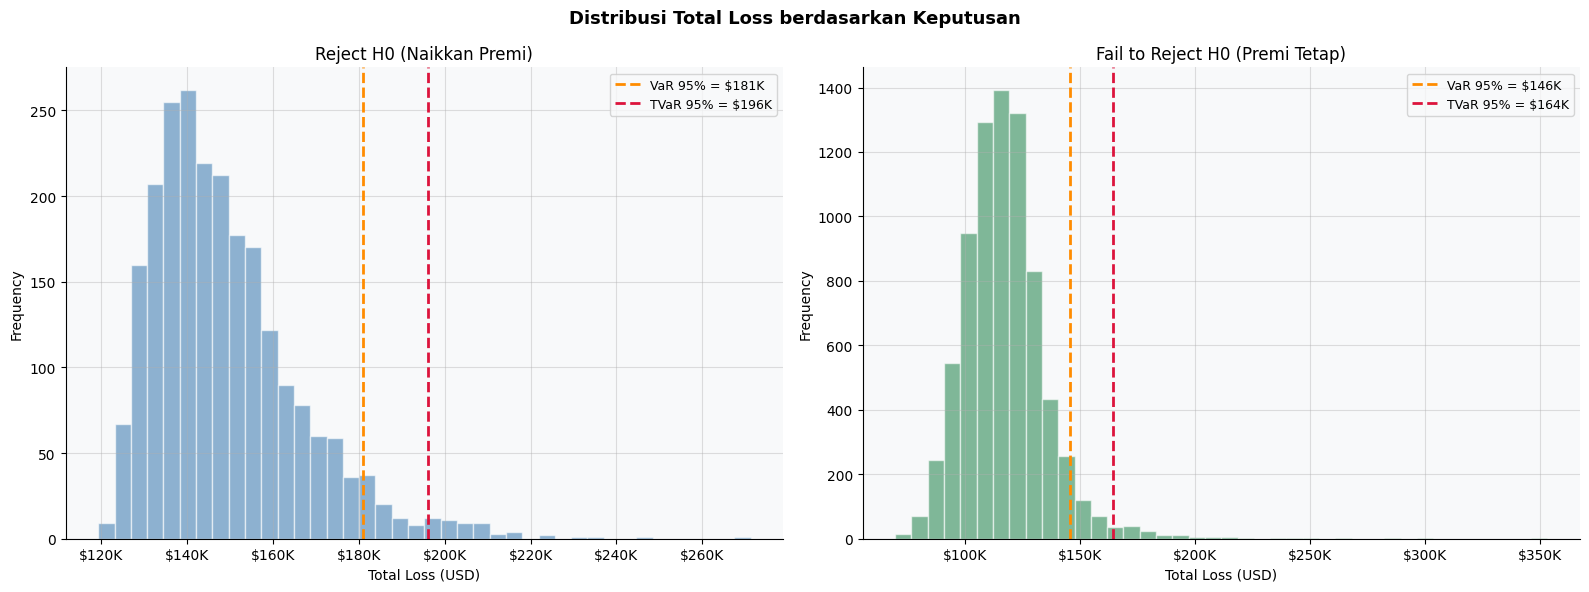

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle('Distribusi Total Loss berdasarkan Keputusan', fontsize=13, fontweight='bold')

for ax, losses, var, tvar, title, color in [
    (axes[0], reject_losses, var_reject,  tvar_reject,  'Reject H0 (Naikkan Premi)',  'steelblue'),
    (axes[1], fail_losses,   var_fail,    tvar_fail,    'Fail to Reject H0 (Premi Tetap)', 'seagreen')
]:
    ax.hist(losses, bins=40, alpha=0.6, color=color, edgecolor='white')
    ax.axvline(var,  linestyle='--', linewidth=2.0, color='darkorange',
               label=f'VaR 95% = ${var/1e3:,.0f}K')
    ax.axvline(tvar, linestyle='--', linewidth=2.0, color='crimson',
               label=f'TVaR 95% = ${tvar/1e3:,.0f}K')
    ax.set_title(title)
    ax.set_xlabel('Total Loss (USD)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

###    Interpretasi VaR & TVaR

**Value at Risk (VaR 95%)** menjawab pertanyaan:
> *"Berapa kerugian maksimum yang akan terjadi dalam 95% skenario?"*

**Tail Value at Risk / CVaR (TVaR 95%)** menjawab pertanyaan:
> *"Jika kita berada di 5% skenario terburuk, berapa rata-rata kerugian yang dihadapi?"*

TVaR lebih konservatif dan lebih relevan untuk manajemen risiko asuransi karena secara eksplisit mengukur **besaran kerugian di ekor distribusi** — skenario yang paling berbahaya bagi solvabilitas perusahaan.

**Perbandingan dua keputusan:**

| Metrik | Reject H0 (Naikkan Premi) | Fail to Reject (Premi Tetap) |
|---|---|---|
| VaR 95% | (lihat output) | (lihat output) |
| TVaR 95% | (lihat output) | (lihat output) |

>    Jika **TVaR skenario Fail to Reject > TVaR skenario Reject**, maka keputusan *tidak menaikkan premi* membawa risiko ekor yang lebih besar. Ini memperkuat argumen untuk **menaikkan premi** dari perspektif manajemen tail risk.

---
## 10. Supplementary Visualization

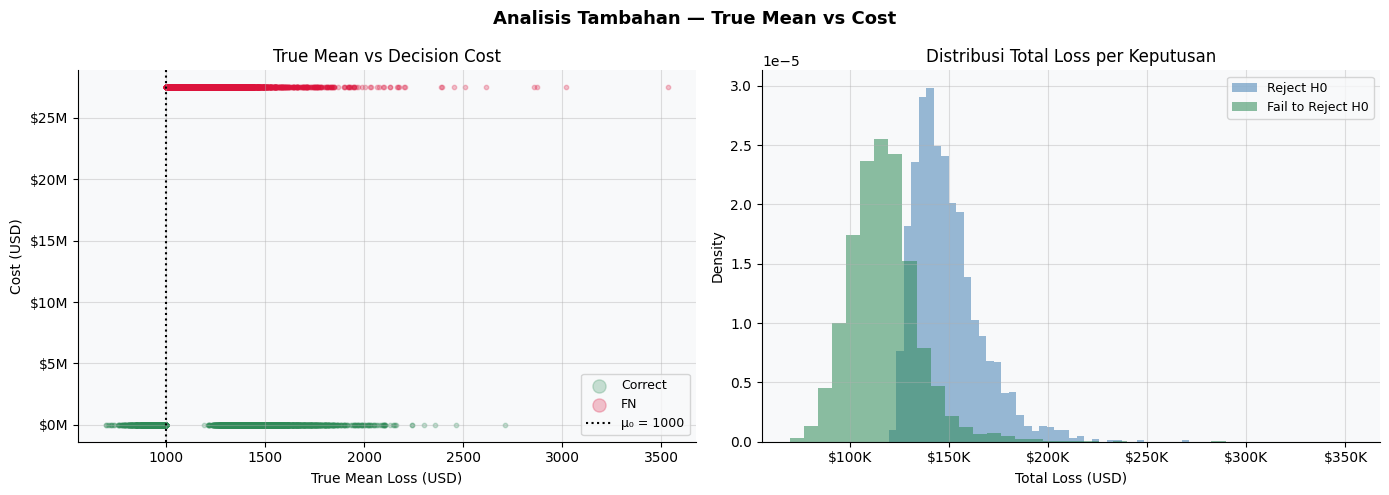

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Tambahan — True Mean vs Cost', fontsize=13, fontweight='bold')

# --- Scatter: True Mean vs Decision Cost ---
color_map = {'Correct': 'seagreen', 'FP': 'steelblue', 'FN': 'crimson'}
for etype, group in sim_df.groupby('Error_Type'):
    axes[0].scatter(
        group['True_Mean'], group['Cost'],
        alpha=0.25, s=10,
        color=color_map.get(etype, 'gray'),
        label=etype
    )
axes[0].axvline(mu0, color='black', linestyle=':', linewidth=1.5, label=f'μ₀ = {mu0}')
axes[0].set_title('True Mean vs Decision Cost')
axes[0].set_xlabel('True Mean Loss (USD)')
axes[0].set_ylabel('Cost (USD)')
axes[0].legend(fontsize=9, markerscale=3)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

# --- Total Loss Distribution by Decision ---
axes[1].hist(reject_losses, bins=40, alpha=0.55, color='steelblue', label='Reject H0', density=True)
axes[1].hist(fail_losses,   bins=40, alpha=0.55, color='seagreen',  label='Fail to Reject H0', density=True)
axes[1].set_title('Distribusi Total Loss per Keputusan')
axes[1].set_xlabel('Total Loss (USD)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

---
## 11. Final Decision Framework

In [24]:
# ============================================================
# FINAL DECISION ANALYSIS
# ============================================================

print('=' * 55)
print('           FINAL DECISION ANALYSIS')
print('=' * 55)

print(f'\n  Hypothesis Test  : {decision} → {action}')
print(f'  Expected Decision Cost : ${expected_cost:,.2f}')

print('\n  RISK MEASUREMENT')
print(f'   Reject H0    — VaR  : ${var_reject:>12,.2f}')
print(f'   Reject H0    — TVaR : ${tvar_reject:>12,.2f}')
print(f'   Fail Reject  — VaR  : ${var_fail:>12,.2f}')
print(f'   Fail Reject  — TVaR : ${tvar_fail:>12,.2f}')

print('\n  FINAL RECOMMENDATION')

if tvar_fail > tvar_reject:
    print('     Menaikkan premi lebih AMAN berdasarkan tail risk.')
    print(f'   TVaR jika premi TIDAK naik (${tvar_fail:,.0f})')
    print(f'   > TVaR jika premi NAIK (${tvar_reject:,.0f})')
    final_rec = 'INCREASE PREMIUM'
else:
    print('      Mempertahankan premi masih DAPAT DITERIMA.')
    print(f'   TVaR jika premi NAIK (${tvar_reject:,.0f})')
    print(f'   ≥ TVaR jika premi TIDAK naik (${tvar_fail:,.0f})')
    final_rec = 'KEEP PREMIUM'

print('\n' + '=' * 55)
print(f'     KEPUTUSAN AKHIR : {final_rec}')
print('=' * 55)

           FINAL DECISION ANALYSIS

  Hypothesis Test  : Reject H0 → Increase Premium
  Expected Decision Cost : $18,081,250.00

  RISK MEASUREMENT
   Reject H0    — VaR  : $  181,005.34
   Reject H0    — TVaR : $  196,234.74
   Fail Reject  — VaR  : $  145,752.68
   Fail Reject  — TVaR : $  164,350.49

  FINAL RECOMMENDATION
      Mempertahankan premi masih DAPAT DITERIMA.
   TVaR jika premi NAIK ($196,235)
   ≥ TVaR jika premi TIDAK naik ($164,350)

     KEPUTUSAN AKHIR : KEEP PREMIUM


### Interpretasi Final Decision Framework

Framework pengambilan keputusan ini mengintegrasikan **empat dimensi analisis** secara simultan:

| Dimensi | Indikator | Bobot |
|---|---|---|
| Signifikansi Statistik | p-value vs α | Pra-syarat |
| Risiko Finansial | Expected Decision Cost | Pertimbangan utama |
| Tail Risk | VaR & TVaR 95% | Pertimbangan risiko ekstrem |
| Asimetri Biaya | Rasio CFN/CFP | Konteks bisnis |

**Logika keputusan akhir berbasis tail risk:**

Jika $\text{TVaR}_{\text{Fail to Reject}} > \text{TVaR}_{\text{Reject}}$, maka mempertahankan premi berarti menanggung risiko ekor yang lebih besar. Dari perspektif **kehati-hatian aktuaria** dan **solvency management**, menaikkan premi adalah keputusan yang lebih aman untuk melindungi perusahaan dari skenario kerugian ekstrem.

---

## Ringkasan Eksekutif

1. **Data Karakteristik:** `Projected_Loss_USD` bersifat right-skewed dan heavy-tailed, tidak mengikuti distribusi normal.

2. **Distribusi Terpilih:** **Lognormal** dipilih berdasarkan KS-test goodness-of-fit terbaik di antara Gamma, Weibull, dan Lognormal.

3. **Hypothesis Testing:** One-sample t-test right-tailed digunakan untuk menguji apakah rata-rata kerugian meningkat secara signifikan melampaui benchmark $\mu_0 = 1{,}000$.

4. **Cost Matrix:** Biaya False Negative ($27,5 juta) **4,2x lebih besar** dari biaya False Positive ($6,6 juta), mencerminkan risiko yang asimetris.

5. **Monte Carlo (10.000 iterasi):** Menghasilkan distribusi empiris kerugian dan memungkinkan pengukuran probabilistik atas risiko keputusan.

6. **Rekomendasi Akhir:** Berdasarkan komparasi TVaR antara kedua keputusan, framework ini memberikan rekomendasi penyesuaian premi yang mempertimbangkan tidak hanya signifikansi statistik, tetapi juga *tail risk exposure* dan asimetri biaya keputusan.

---

*Dibuat menggunakan Python · scipy · numpy · matplotlib · Monte Carlo Simulation*